In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.datasets import fetch_california_housing

# dataset = fetch_openml(name="boston", version=1, as_frame=True)
dataset = fetch_california_housing(as_frame=True)
# dataset = fetch_openml(name="house_prices", as_frame=True)
dataset = dataset.frame

# dataset = dataset[dataset['SalePrice'].notna()]

print('(#Data,#Features):',dataset.shape)
print()
feature_names = list(dataset.columns)
print("Feature names:", feature_names)
print()
null_counts = dataset.isnull().sum()
print(null_counts[null_counts > 0])
print()
# print('5 first rows:')
# print()
# print(dataset.head(5))

(#Data,#Features): (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Series([], dtype: int64)



In [3]:
# # new_dataset= dataset.drop(['Id'], axis=1, inplace=False)

# new_dataset = new_dataset.dropna(subset=['SalePrice'])
new_dataset = dataset
# Fill missing values
numeric_cols = new_dataset.select_dtypes(include=['number']).columns
new_dataset[numeric_cols] = new_dataset[numeric_cols].fillna(new_dataset[numeric_cols].median())

# For categorical columns: fill with mode or 'Unknown'
object_cols = new_dataset.select_dtypes(include=['object']).columns
new_dataset[object_cols] = new_dataset[object_cols].fillna('Unknown')
object_cols = new_dataset.select_dtypes(include=['object']).columns
new_dataset[object_cols] = new_dataset[object_cols].fillna('Unknown')

null_counts = new_dataset.isnull().sum()
print(null_counts[null_counts > 0])

# Feature engineering
new_dataset['RoomsPerHousehold'] = new_dataset['AveRooms'] / new_dataset['AveOccup']
new_dataset['BedroomsPerRoom'] = new_dataset['AveBedrms'] / new_dataset['AveRooms']
new_dataset['PopulationPerHousehold'] = new_dataset['Population'] / new_dataset['HouseAge']
print()
print('(#Data,#Features):',new_dataset.shape)

Series([], dtype: int64)

(#Data,#Features): (20640, 12)


In [4]:
obj = (new_dataset.dtypes == 'category')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))
print()

int_ = (new_dataset.dtypes == 'int64')
num_cols = list(int_[int_].index)
print("Integer variables:", len(num_cols))
print()

fl = (new_dataset.dtypes == 'float64')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Categorical variables: 0

Integer variables: 0

Float variables: 12


<Axes: >

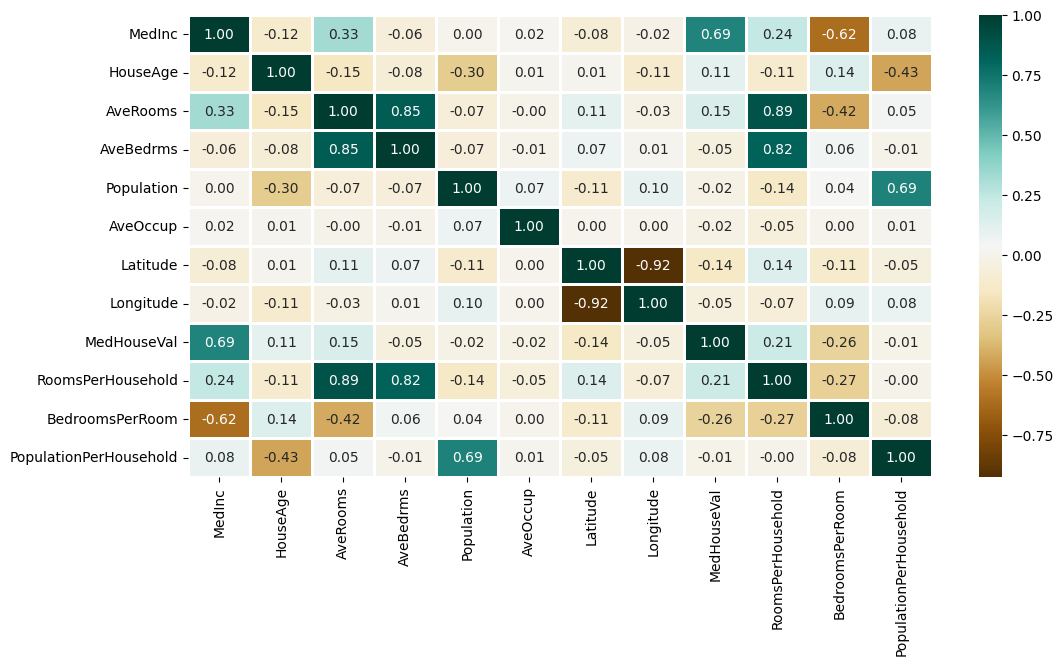

In [5]:
numerical_dataset = new_dataset.select_dtypes(include=['number'])
plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(), cmap = 'BrBG', fmt = '.2f', linewidths = 2, annot = True)

<Axes: title={'center': 'No. Unique values of Categorical Features'}>

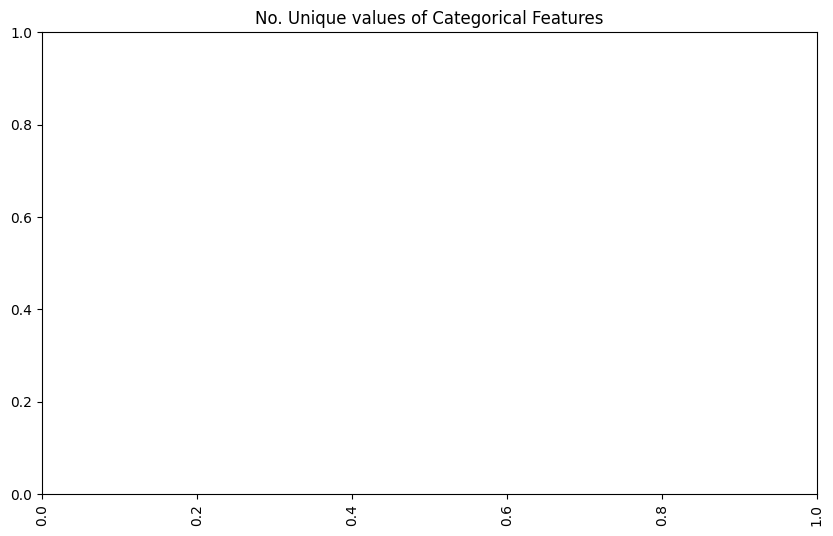

In [6]:
unique_values = []
unique_values_count = []
for col in object_cols:
    unique_values_count.append(new_dataset[col].unique().size)
    print(f"{col}: {new_dataset[col].unique()}")   
    print(f"{col}: {new_dataset[col].unique().size}")

plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values_count)

In [7]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'category')
object_cols = list(s[s].index)
print("Categorical variables:", object_cols)

OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
# print(OH_cols)
OH_cols.index = new_dataset.index
# print(OH_cols.index)
OH_cols.columns = OH_encoder.get_feature_names_out()
# print(OH_cols.columns)
# print(OH_cols)
df_final = new_dataset.drop(object_cols, axis=1)
# print(df_final)
df_final = pd.concat([df_final, OH_cols], axis=1)
print(df_final)

Categorical variables: []
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longit

In [8]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

#X = df_final.drop(['SalePrice'], axis=1)
#Y = df_final['SalePrice']

X = df_final.drop(['MedHouseVal'], axis=1)
Y = df_final['MedHouseVal']

X_train, X_valid, Y_train, Y_valid = train_test_split( X, Y, train_size=0.8, test_size=0.2, random_state=0)

In [9]:
from sklearn import svm
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error

# Creates an SVR model with default parameters (kernel='rbf', C=1.0, epsilon=0.1).
model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)
print(mean_absolute_percentage_error(Y_valid, Y_pred))
# print(mean_absolute_error(Y_valid, Y_pred))

0.5186837906747783


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error

# 1. Create scaler and scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# 2. Create and train model on scaled data
model_SVR = SVR()
model_SVR.fit(X_train_scaled, Y_train)

# 3. Predict using scaled data
Y_pred = model_SVR.predict(X_valid_scaled)

# 4. Evaluate
print("RF MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

RF MAPE: 0.20861548953153913


In [11]:
'''from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'epsilon': [0.001, 0.01, 0.1, 0.5, 1.0],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train_scaled, Y_train)

print(grid_search.best_params_)'''

"from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    'C': [0.01, 0.1, 1, 10, 100, 1000],\n    'epsilon': [0.001, 0.01, 0.1, 0.5, 1.0],\n    'kernel': ['rbf', 'linear', 'poly'],\n    'gamma': ['scale', 'auto', 0.01, 0.1, 1]\n}\n\ngrid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_absolute_error')\ngrid_search.fit(X_train_scaled, Y_train)\n\nprint(grid_search.best_params_)"

In [12]:
model_SVR = SVR(C=1000, epsilon=1, kernel='linear', gamma = 'scale')
model_SVR.fit(X_train_scaled, Y_train)

# 3. Predict using scaled data
Y_pred = model_SVR.predict(X_valid_scaled)

# 4. Evaluate
print("SVR MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

SVR MAPE: 0.3694482585770912


In [13]:
'''from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=0), param_grid, cv=5, scoring='neg_mean_absolute_percentage_error')
grid_search.fit(X_train, Y_train)
print(grid_search.best_params_)'''

"from sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    'n_estimators': [100, 200, 300],\n    'max_depth': [10, 15, 20, None],\n    'min_samples_split': [2, 5, 10]\n}\n\ngrid_search = GridSearchCV(RandomForestRegressor(random_state=0), param_grid, cv=5, scoring='neg_mean_absolute_percentage_error')\ngrid_search.fit(X_train, Y_train)\nprint(grid_search.best_params_)"

In [14]:
from sklearn.ensemble import RandomForestRegressor
model_RFR = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=2,random_state=0)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)
print("RF MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

RF MAPE: 0.19597156247760597


In [15]:
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)
print("LR MAPE:",mean_absolute_percentage_error(Y_valid, Y_pred))

LR MAPE: 0.3020444355796274


In [16]:
'''from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5]
}

grid_search = GridSearchCV(XGBRegressor(random_state=0), param_grid, cv=5, scoring='neg_mean_absolute_percentage_error')
grid_search.fit(X_train, Y_train)
print(grid_search.best_params_)

Y_pred = grid_search.best_estimator_.predict(X_valid)
print(mean_absolute_percentage_error(Y_valid, Y_pred))'''

"from sklearn.model_selection import GridSearchCV\nfrom xgboost import XGBRegressor\n\nparam_grid = {\n    'n_estimators': [100, 200, 300],\n    'max_depth': [3, 5, 7],\n    'learning_rate': [0.01, 0.05, 0.1],\n    'min_child_weight': [1, 3, 5]\n}\n\ngrid_search = GridSearchCV(XGBRegressor(random_state=0), param_grid, cv=5, scoring='neg_mean_absolute_percentage_error')\ngrid_search.fit(X_train, Y_train)\nprint(grid_search.best_params_)\n\nY_pred = grid_search.best_estimator_.predict(X_valid)\nprint(mean_absolute_percentage_error(Y_valid, Y_pred))"

In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=0)
model_gb.fit(X_train, Y_train)
Y_pred_gb = model_gb.predict(X_valid)
print("GB  MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred_gb))

model_xgb = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.05, min_child_weight= 3, random_state=0)
model_xgb.fit(X_train, Y_train)
Y_pred = model_xgb.predict(X_valid)
print("XGB MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

GB  MAPE: 0.21443153306521634
XGB MAPE: 0.17250289428696794


In [18]:
'''from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'min_child_samples': [5, 10, 20]
}

grid_search = GridSearchCV(
    LGBMRegressor(random_state=0, verbose=-1), 
    param_grid, 
    cv=5, 
    scoring='neg_mean_absolute_percentage_error'
)
grid_search.fit(X_train, Y_train)

print("Best params:", grid_search.best_params_)'''

'from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\n    \'n_estimators\': [200, 300, 500],\n    \'max_depth\': [5, 7, 10],\n    \'learning_rate\': [0.01, 0.05, 0.1],\n    \'num_leaves\': [15, 31, 50],\n    \'min_child_samples\': [5, 10, 20]\n}\n\ngrid_search = GridSearchCV(\n    LGBMRegressor(random_state=0, verbose=-1), \n    param_grid, \n    cv=5, \n    scoring=\'neg_mean_absolute_percentage_error\'\n)\ngrid_search.fit(X_train, Y_train)\n\nprint("Best params:", grid_search.best_params_)'

In [19]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    num_leaves=15,
    min_child_samples=5,
    random_state=0,
    verbose=-1)
model_lgbm.fit(X_train, Y_train)
Y_pred = model_lgbm.predict(X_valid)
print("LGBM MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

c:\Users\khate\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\khate\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\khate\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\khate\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

LGBM MAPE: 0.1783490762371412


In [20]:
importance = pd.Series(model_lgbm.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False).head(20))

Latitude                  567
Longitude                 544
MedInc                    351
AveOccup                  283
HouseAge                  203
BedroomsPerRoom           173
AveBedrms                 146
RoomsPerHousehold         143
AveRooms                  137
Population                133
PopulationPerHousehold    120
dtype: int32


In [21]:
print(f"Original columns: {len(dataset.columns)}")
print(dataset.columns.tolist())

# See what you're using
print(f"Your features: {len(X_train.columns)}")

Original columns: 12
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']
Your features: 11


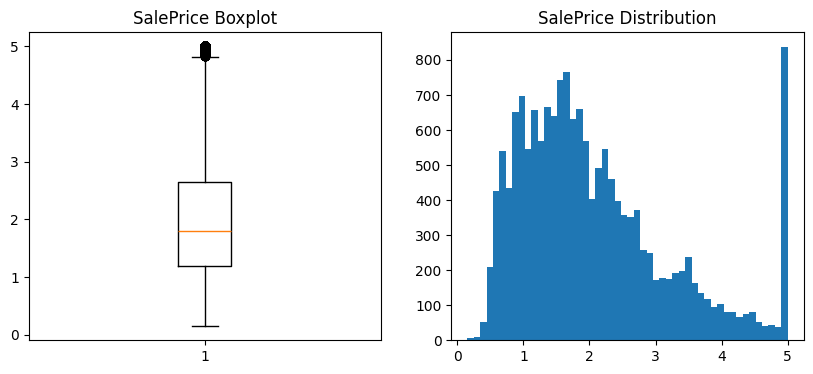

count    16512.000000
mean         2.072499
std          1.156915
min          0.149990
25%          1.200000
50%          1.802500
75%          2.647000
max          5.000010
Name: MedHouseVal, dtype: float64

Lowest: 0.14999
Highest: 5.00001


In [22]:
import matplotlib.pyplot as plt

# Visual check
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.boxplot(Y_train)
plt.title('SalePrice Boxplot')

plt.subplot(1, 2, 2)
plt.hist(Y_train, bins=50)
plt.title('SalePrice Distribution')
plt.show()

# See extreme values
print(Y_train.describe())
print(f"\nLowest: {Y_train.min()}")
print(f"Highest: {Y_train.max()}")

In [23]:
# Remove top 1% and bottom 1%
Q_low = Y_train.quantile(0.01)
Q_high = Y_train.quantile(0.99)

mask = (Y_train >= Q_low) & (Y_train <= Q_high)
X_train_clean = X_train[mask]
Y_train_clean = Y_train[mask]

print(f"Before: {len(X_train)} rows")
print(f"After: {len(X_train_clean)} rows")

Before: 16512 rows
After: 16349 rows


In [24]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    num_leaves=15,
    min_child_samples=5,
    random_state=0,
    verbose=-1)
model_lgbm.fit(X_train_clean, Y_train_clean)
Y_pred = model_lgbm.predict(X_valid)
print("LGBM MAPE:", mean_absolute_percentage_error(Y_valid, Y_pred))

LGBM MAPE: 0.1812291419791647
